# Phase 3: Reconstruction Interpretability (25 Marks)

**Team Astra** | NSSC 2026 | IIT Kharagpur  
**Lead:**

---

## Objectives
1. Select the **top 5 most anomalous images** that strictly exceed the threshold
2. Compute **per-pixel absolute error** between original and reconstruction
3. Render as **overlay heatmaps** (3-panel: Original | Reconstruction | Error)
4. Provide a **geological hypothesis** for each flagged image

### Physical Interpretation Guidelines
- Sharp linear features → spliced boundary artifact
- Diffuse errors → domain shift or sensor calibration change
- Periodic stripes → sensor readout / hardware glitch
- Localized bright spots → terrestrial interference injection
- Uniform elevated error → contrast/exposure anomaly

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/hackysoham/ASTRA.git
%cd ASTRA

Mounted at /content/drive
Cloning into 'ASTRA'...
remote: Enumerating objects: 647, done.
remote: Counting objects: 100% (647/647), done.
remote: Compressing objects: 100% (645/645), done.
remote: Total 647 (delta 0), reused 647 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (647/647), 8.20 MiB | 19.26 MiB/s, done.
/content/ASTRA


In [2]:
import zipfile
import os

DRIVE_BASE = '/content/drive/MyDrive/nssc2026'
ASTRA_ROOT = '/content/ASTRA'

# Phase 1 outputs — contains model checkpoints + latent vectors
with zipfile.ZipFile(f'{DRIVE_BASE}/phase1_all_outputs.zip') as z:
    z.extractall(f'{ASTRA_ROOT}/outputs')

# Phase 2 outputs — contains novelty scores + plots
with zipfile.ZipFile(f'{DRIVE_BASE}/phase2_all_outputs.zip') as z:
    z.extractall(f'{ASTRA_ROOT}/outputs')

# Sanity check — confirm the model checkpoint actually landed where Phase 3 expects it
print(os.path.exists(f'{ASTRA_ROOT}/outputs/models/best_v5.pth'))
print(os.listdir(f'{ASTRA_ROOT}/outputs') if os.path.exists(f'{ASTRA_ROOT}/outputs') else 'outputs/ missing')

True
['novelty_scores_v5.csv', 'latent_vectors', 'models', 'plots']


In [3]:
with zipfile.ZipFile(f'{DRIVE_BASE}/images.zip') as z:
    z.extractall(f'{ASTRA_ROOT}/data/images')

import shutil
shutil.copy(f'{DRIVE_BASE}/crop_metadata_index.csv', f'{ASTRA_ROOT}/data/')
shutil.copy(f'{DRIVE_BASE}/source_image_metadata.csv', f'{ASTRA_ROOT}/data/')

'/content/ASTRA/data/source_image_metadata.csv'

In [16]:
# ─── System Setup ─────────────────────────────────────────────────────
import sys
import os

PROJECT_ROOT = '/content/ASTRA'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

IMAGE_DIR = os.path.join(PROJECT_ROOT, 'data', 'images')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'models')
LATENT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'latent_vectors')
PLOTS_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'plots')
SCORES_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'scores')
REPORT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'report')
CROP_METADATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'crop_metadata_index.csv')

In [5]:
# ─── Imports ──────────────────────────────────────────────────────────
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import set_seed, get_device
from src.dataset import create_dataloaders
from src.models import get_model
from src.latent_utils import load_latents
from src.heatmaps import (
    top_k_anomaly_panels,
    generate_geological_report,
)

set_seed(42)
device = get_device()
print('Phase 3 imports ready.')

[Device] Using CPU
Phase 3 imports ready.


In [9]:
import os
os.chdir('/content/ASTRA')
print(os.getcwd())

/content/ASTRA


In [13]:
!ls /content/ASTRA/outputs/
!ls /content/ASTRA/outputs/scores/ 2>&1

latent_vectors	models	plots  scores
novelty_scores_v5.csv


In [12]:
import os

os.makedirs('/content/ASTRA/outputs/scores', exist_ok=True)
os.rename(
    '/content/ASTRA/outputs/novelty_scores_v5.csv',
    '/content/ASTRA/outputs/scores/novelty_scores_v5.csv'
)

!ls /content/ASTRA/outputs/scores/

novelty_scores_v5.csv


In [11]:
!find /content -maxdepth 4 -iname "best_v5.pth" 2>/dev/null
!echo "---"
!pwd

/content/ASTRA/outputs/models/best_v5.pth
---
/content/ASTRA


## 3.1 Load Best Model & Scores

In [14]:
BEST_VERSION = 'v5'

# Load the best model checkpoint
model = get_model(BEST_VERSION)
checkpoint = torch.load(
    os.path.join(MODELS_DIR, f'best_{BEST_VERSION}.pth'),
    map_location=device,
    weights_only=False,
)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()
print(f'Model {BEST_VERSION.upper()} loaded (epoch {checkpoint["epoch"]})')

# Load scores
scores_df = pd.read_csv(
    os.path.join(SCORES_DIR, f'novelty_scores_{BEST_VERSION}.csv')
)
print(f'Scores loaded: {len(scores_df)} images')
print(f'Anomalies flagged: {scores_df["is_anomaly"].sum()}')

[Model] V5 | AEv5 | latent=256 | params=25,557,825 | VAE=True
Model V5 loaded (epoch 50)
Scores loaded: 10422 images
Anomalies flagged: 125


In [18]:
!ls /content/ASTRA/data/images/ | head -20
!find /content/ASTRA/data/images -type f | wc -l

images
10422


In [19]:
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/nssc2026/images.zip') as z:
    names = z.namelist()
    print(names[:10])
    print(f'Total entries: {len(names)}')

['images/', 'images/sample_00001.jpg', 'images/sample_00002.jpg', 'images/sample_00003.jpg', 'images/sample_00004.jpg', 'images/sample_00005.jpg', 'images/sample_00006.jpg', 'images/sample_00007.jpg', 'images/sample_00008.jpg', 'images/sample_00009.jpg']
Total entries: 10423


In [20]:
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/nssc2026/images.zip') as z:
    z.extractall('/content/ASTRA/data')  # let the zip's own 'images/' folder land here

In [21]:
# Create full data loader
_, _, full_loader = create_dataloaders(
    image_dir=IMAGE_DIR,
    metadata_csv=CROP_METADATA_PATH,
    batch_size=32,
    val_split=0.1,
    num_workers=4,
)

# Get scores and filenames in dataset order
latents, filenames = load_latents(save_dir=LATENT_DIR, version=BEST_VERSION)

# Map filenames to scores
score_map = dict(zip(scores_df['filename'], scores_df['novelty_score']))
scores = np.array([score_map.get(fn, 0.0) for fn in filenames])

# Get effective threshold from consensus
anomaly_mask = scores_df[scores_df['is_anomaly'] == True]
if len(anomaly_mask) > 0:
    effective_threshold = anomaly_mask['novelty_score'].min()
else:
    effective_threshold = np.percentile(scores, 99)

print(f'Effective threshold: {effective_threshold:.6f}')
print(f'Images exceeding threshold: {(scores > effective_threshold).sum()}')

[Dataset] Loaded 10422 crops from /content/ASTRA/data/images (CSV: crop_metadata_index.csv)
[Split] Train: 9380 | Val: 1042
[Latent] Loaded 10422 vectors of dim 256
Effective threshold: 0.211996
Images exceeding threshold: 70


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 3.2 Generate Top-5 Anomaly Heatmaps

For each of the top-5 most anomalous images (strictly exceeding the threshold), we:
1. Pass through the autoencoder to get the reconstruction
2. Compute per-pixel absolute error: $E(i,j) = |X(i,j) - \hat{X}(i,j)|$
3. Render as a 3-panel figure: **Original** | **Reconstruction** | **Error Heatmap**

In [22]:
# Generate heatmap panels for top-5 anomalies
anomaly_results = top_k_anomaly_panels(
    model=model,
    loader=full_loader,
    device=device,
    scores=scores,
    filenames=filenames,
    threshold=effective_threshold,
    k=5,
    save_dir=PLOTS_DIR,

)

print(f'\nGenerated heatmaps for {len(anomaly_results)} anomalies')

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Generated heatmaps for 5 anomalies


In [23]:
!ls /content/ASTRA/outputs/plots/ | grep anomaly_rank

anomaly_rank01_sample_10365.jpg.png
anomaly_rank02_sample_06556.jpg.png
anomaly_rank03_sample_07293.jpg.png
anomaly_rank04_sample_06855.jpg.png
anomaly_rank05_sample_06495.jpg.png


Found 5 files
anomaly_rank01_sample_10365.jpg.png


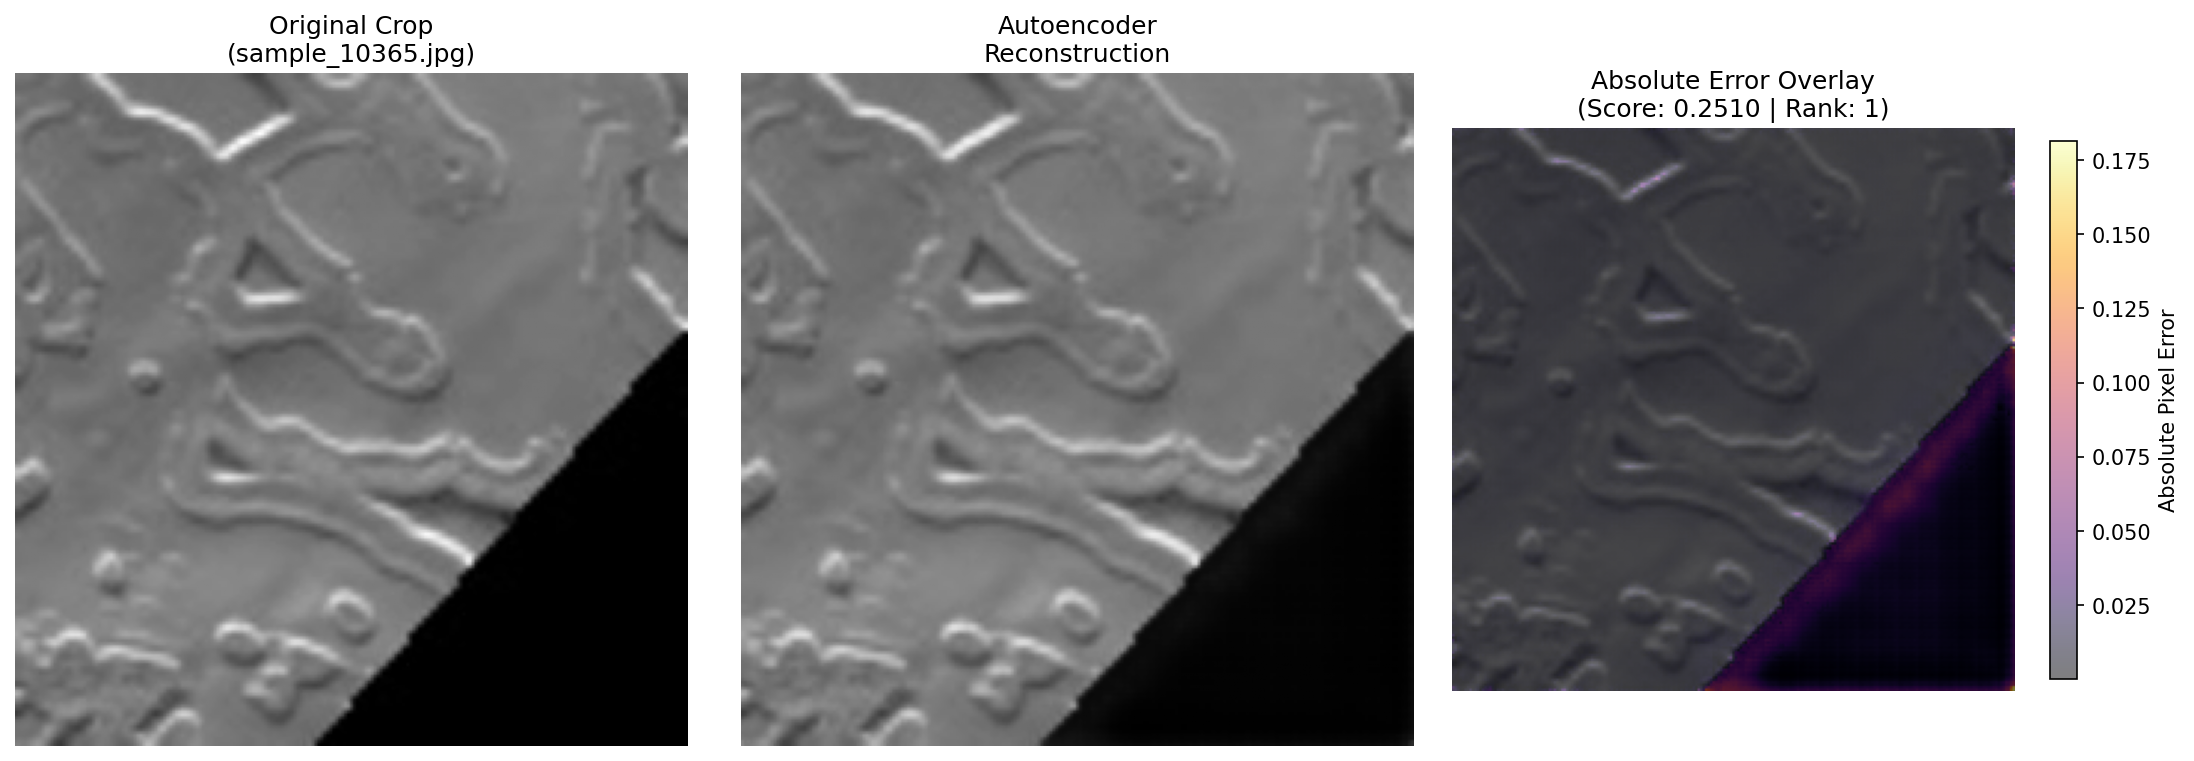

anomaly_rank02_sample_06556.jpg.png


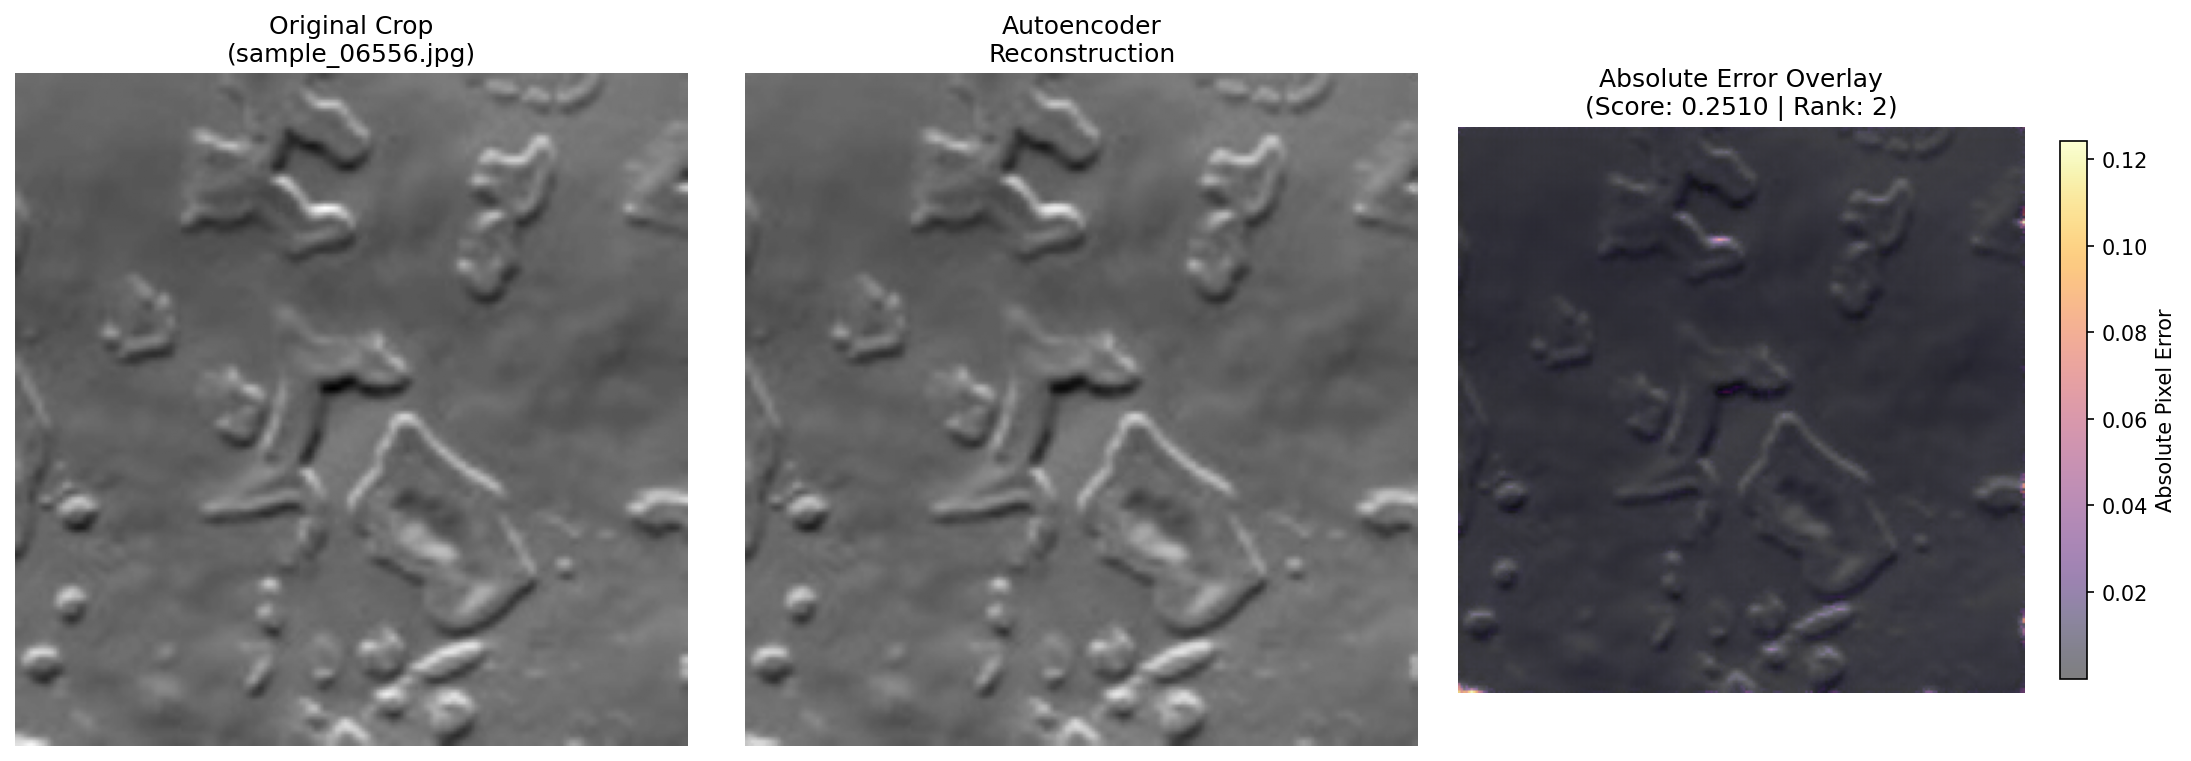

anomaly_rank03_sample_07293.jpg.png


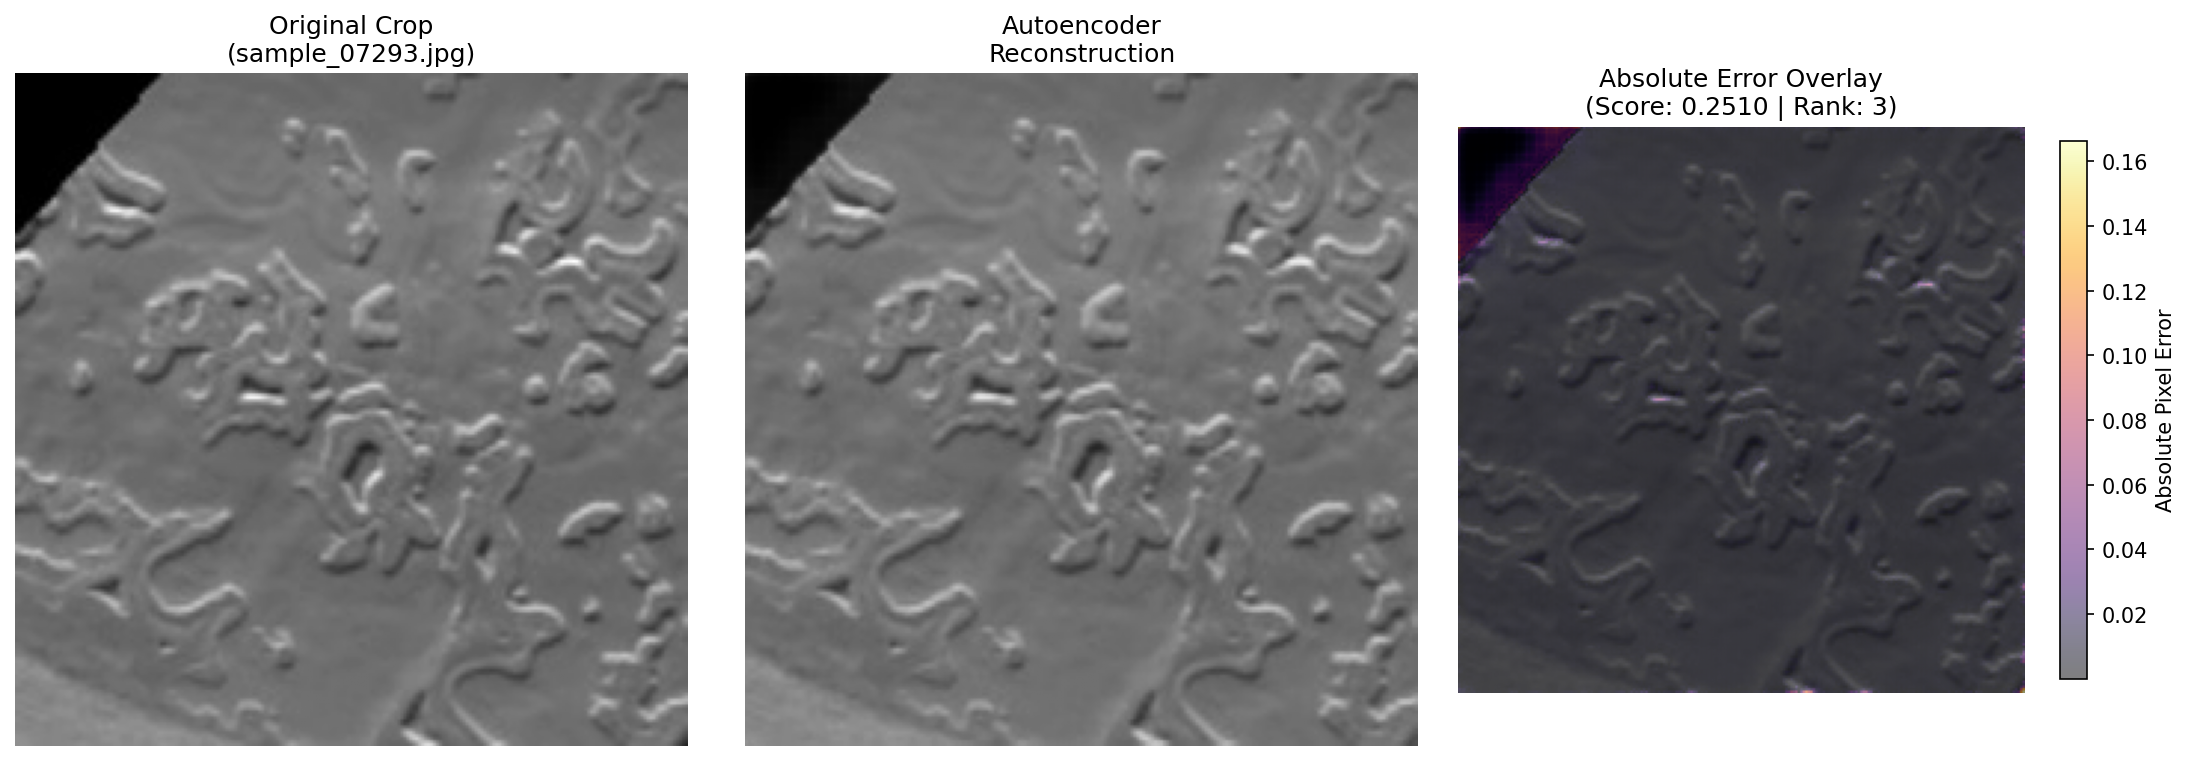

anomaly_rank04_sample_06855.jpg.png


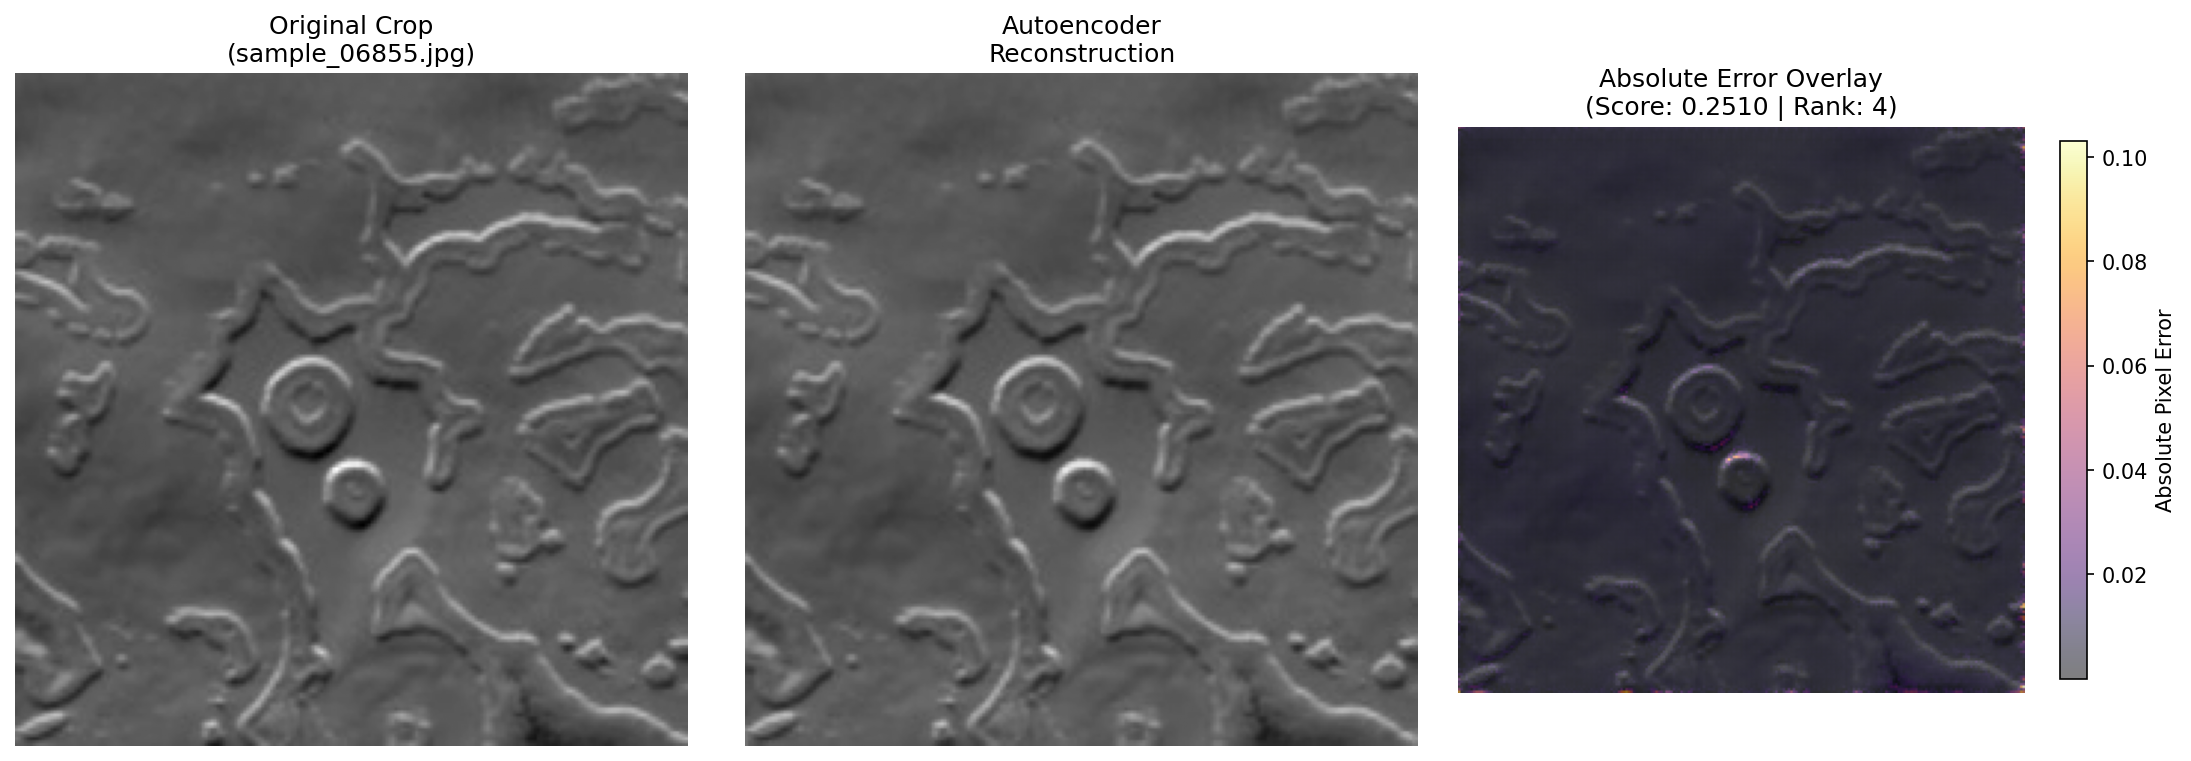

anomaly_rank05_sample_06495.jpg.png


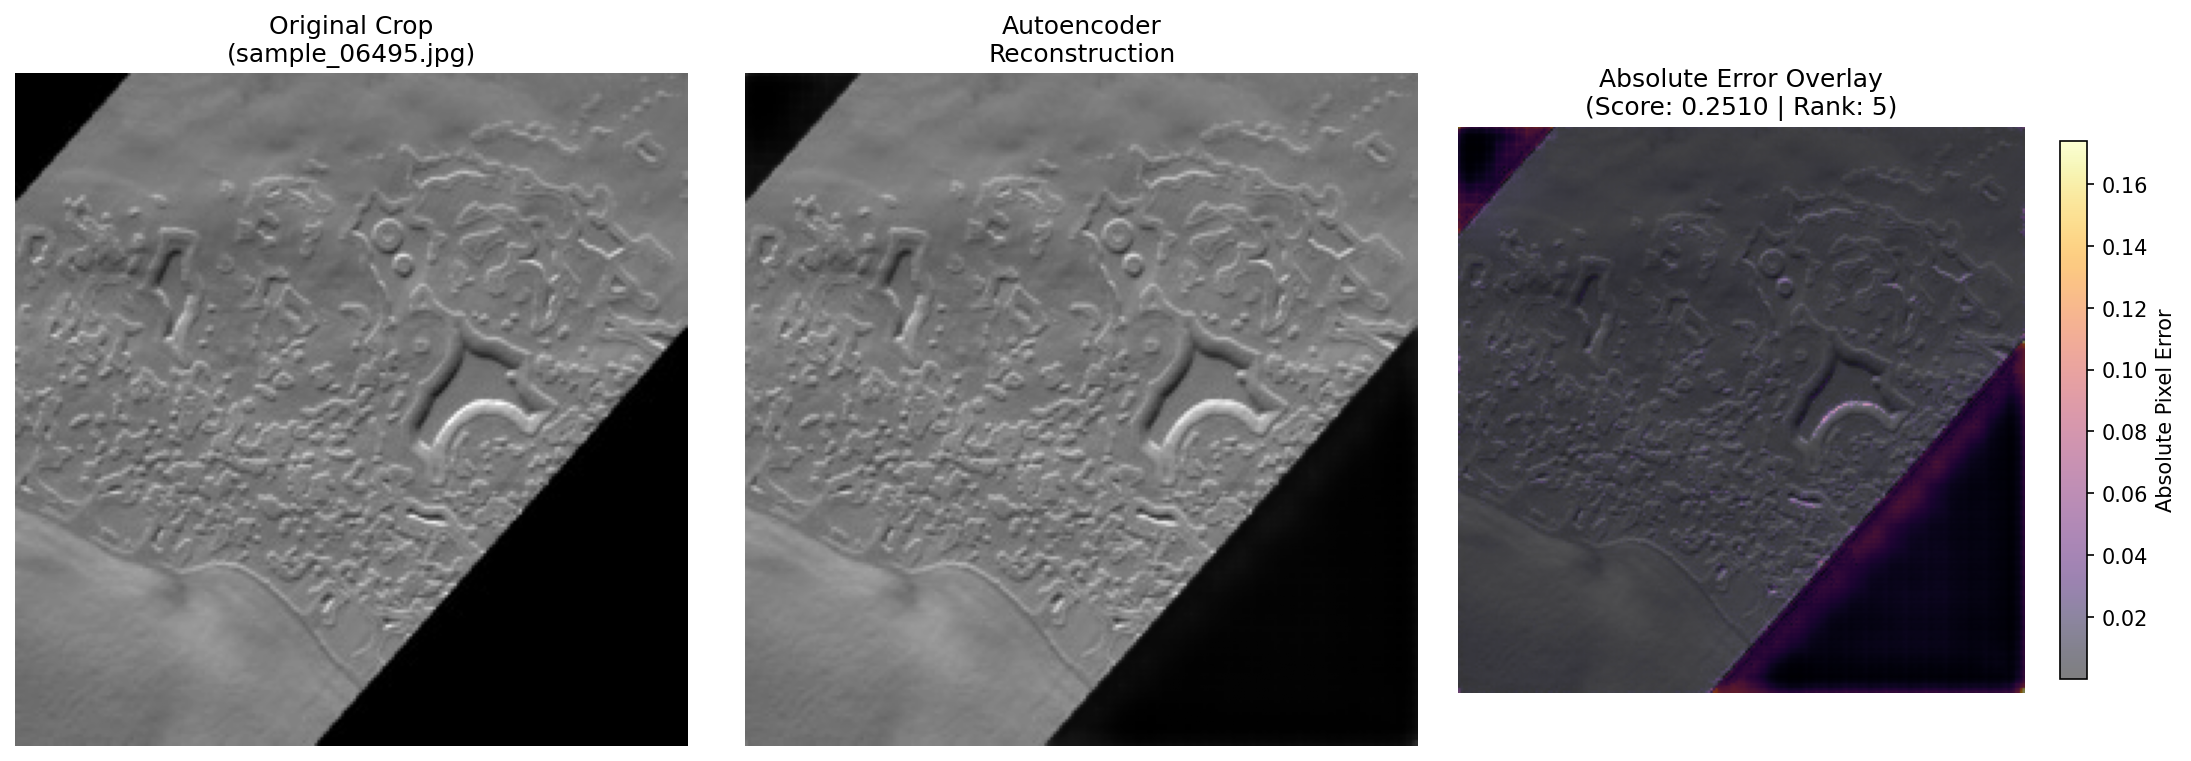

In [29]:
from IPython.display import Image as IPImage, display
import glob

heatmap_files = sorted(glob.glob('/content/ASTRA/outputs/plots/anomaly_rank*.png'))
print(f'Found {len(heatmap_files)} files')

for f in heatmap_files:
    print(f.split('/')[-1])
    display(IPImage(filename=f))

## 3.3 Geological Hypothesis Report

In [30]:
from src.heatmaps import analyze_error_pattern

results_df = pd.DataFrame(anomaly_results)
print('\n' + '=' * 80)
print('  GEOLOGICAL HYPOTHESIS REPORT — TOP 5 ANOMALIES')
print('=' * 80)

for r in anomaly_results:
    hypothesis = analyze_error_pattern(r)
    print(f'\n  Anomaly #{r["rank"]} — {r["filename"]}')
    print(f'  Novelty Score: {r["score"]:.4f}')
    print(f'  Mean Error:    {r["mean_error"]:.4f}')
    print(f'  Max Error:     {r["max_error"]:.4f}')
    print(f'  Error Pattern: {r["pattern"]}')
    print(f'  Hypothesis:    {hypothesis}')
    print('  ' + '─' * 76)


  GEOLOGICAL HYPOTHESIS REPORT — TOP 5 ANOMALIES

  Anomaly #1 — sample_10365.jpg
  Novelty Score: 0.2510
  Mean Error:    0.0073
  Max Error:     0.1817
  Error Pattern: Diffuse, uniform
  Hypothesis:    The error is diffusely spread across the entire crop with elevated mean residuals. This suggests a significant domain shift — possibly a sensor calibration change, extreme contrast/exposure anomaly, or a terrain type completely absent from the training distribution.
  ────────────────────────────────────────────────────────────────────────────

  Anomaly #2 — sample_06556.jpg
  Novelty Score: 0.2510
  Mean Error:    0.0044
  Max Error:     0.1242
  Error Pattern: Diffuse, uniform
  Hypothesis:    The error is diffusely spread across the entire crop with elevated mean residuals. This suggests a significant domain shift — possibly a sensor calibration change, extreme contrast/exposure anomaly, or a terrain type completely absent from the training distribution.
  ───────────────────────

In [31]:
# Generate markdown report
report = generate_geological_report(
    anomaly_results=anomaly_results,
    save_path=os.path.join(REPORT_DIR, 'geological_report.md'),
)

print('\n✓ Phase 3 complete. Heatmaps and geological report saved.')

[heatmaps] Geological report saved to /content/ASTRA/outputs/report/geological_report.md

✓ Phase 3 complete. Heatmaps and geological report saved.


In [37]:
!ls -la /content/ASTRA/outputs/report/
!cat /content/ASTRA/outputs/report/geological_report.md

total 12
drwxr-xr-x 2 root root 4096 Sep 17 23:36 .
drwxr-xr-x 7 root root 4096 Sep 17 23:36 ..
-rw-r--r-- 1 root root 2552 Sep 17 23:36 geological_report.md
# Phase 3.2: Geological Analysis of Top Anomalies

**Team Astra** | NSSC 2026 | IIT Kharagpur

This report details the physical hypotheses for the top-ranked anomalies strictly exceeding the KDE knee threshold. The analysis correlates spatial error distributions with potential Martian terrain features, sensor artifacts, or synthetic data injections.

---

## Rank 1 — Image: `sample_10365.jpg`
- **Novelty Score:** 0.2510
- **Max Absolute Error:** 0.1817
- **Error Pattern:** Diffuse, uniform

### Physical Hypothesis
The error is diffusely spread across the entire crop with elevated mean residuals. This suggests a significant domain shift — possibly a sensor calibration change, extreme contrast/exposure anomaly, or a terrain type completely absent from the training distribution.

---

## Rank 2 — Image: `sample_06556.jpg`
- **Novelty

In [39]:
import json

# Save anomaly_results as JSON
with open('/content/ASTRA/outputs/report/anomaly_results.json', 'w') as f:
    json.dump(anomaly_results, f, indent=2)

print("Saved anomaly_results.json")

Saved anomaly_results.json


In [40]:
!ls -la /content/ASTRA/outputs/report/
!cat /content/ASTRA/outputs/report/geological_report.md

total 16
drwxr-xr-x 2 root root 4096 Sep 18 00:01 .
drwxr-xr-x 7 root root 4096 Sep 17 23:36 ..
-rw-r--r-- 1 root root 1026 Sep 18 00:03 anomaly_results.json
-rw-r--r-- 1 root root 2552 Sep 17 23:36 geological_report.md
# Phase 3.2: Geological Analysis of Top Anomalies

**Team Astra** | NSSC 2026 | IIT Kharagpur

This report details the physical hypotheses for the top-ranked anomalies strictly exceeding the KDE knee threshold. The analysis correlates spatial error distributions with potential Martian terrain features, sensor artifacts, or synthetic data injections.

---

## Rank 1 — Image: `sample_10365.jpg`
- **Novelty Score:** 0.2510
- **Max Absolute Error:** 0.1817
- **Error Pattern:** Diffuse, uniform

### Physical Hypothesis
The error is diffusely spread across the entire crop with elevated mean residuals. This suggests a significant domain shift — possibly a sensor calibration change, extreme contrast/exposure anomaly, or a terrain type completely absent from the training distrib

In [41]:
import shutil

shutil.make_archive(
    '/content/drive/MyDrive/nssc2026/phase3_all_outputs',
    'zip',
    '/content/ASTRA/outputs'
)
print("Saved to Drive: phase3_all_outputs.zip")

Saved to Drive: phase3_all_outputs.zip
